
<br/>
<b>Última actualización</b>:28 de octubre
<hr/>

In [ ]:
!pip install -q gdown

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
from scipy.interpolate import interp1d

from scipy.stats import norm


In [ ]:
!gdown --id 1hDBmOptCvLC8Gulc602ceHw0kJKYR5WK  > /dev/null
!unzip -o sample_flatszip  > /dev/null

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1hDBmOptCvLC8Gulc602ceHw0kJKYR5WK
To: /content/sample_flatszip.zip
100% 221M/221M [00:01<00:00, 214MB/s]
mapname:  conversion of  failed


In [ ]:
ruta_archivo = '/content/flat_0006.pix.gz'



# Lee el archivo de texto en un DataFrame de Pandas
data = pd.read_csv(ruta_archivo, sep='\s+', header=None, names=["Coordenada x", "Coordenada y", "I(x,y)"], dtype={"Columna3": int})

# Muestra el DataFrame
data



,Coordenada x,Coordenada y,"I(x,y)"
0,1.0,1.0,1214.0
1,2.0,1.0,2550.0
2,3.0,1.0,3344.0
3,4.0,1.0,3654.0
4,5.0,1.0,3744.0
...,...,...,...
4194299,2044.0,2048.0,22269.0
4194300,2045.0,2048.0,22728.0
4194301,2046.0,2048.0,22614.0
4194302,2047.0,2048.0,22336.0


In [ ]:
data.iloc[0] #FILAS

Coordenada x       1.0
Coordenada y       1.0
I(x,y)          1214.0
Name: 0, dtype: float64

In [ ]:
I=np.array(data.iloc[:, 2]) #COLUMNAS
x=np.array(data.iloc[:, 0])
y=np.array(data.iloc[:, 1])

NameError: ignored

In [ ]:
sum(I)

167601501513.0

## **a)**

### **Calculo de momentos**

 Calcule los momentos de la distribución de intensidades del flat field

La media, la varianza, el skewness y la curtosis son los llamados momentos de una distribución. El tercer y cuarto momento, corresponden a las medidas de forma de una distribución que toman como referencia a la distribución normal. La curtosis mide el grado en que una distribución se aleja de la distribución normal, respecto al nivel de achatamiento o apuntamiento de su curva, estudiando la concentración de valores en la zona de la media, cuanto mayor sea la concentración en esta zona, mayor será su apuntamiento, por el contrario, si la concentración en la zona central es baja se dirá que la curva achatada (Fernández et al., 2002). Esto es lo que se habla acerca del apuntamiento, Sin embargo hay otra interpretación asociada al **comportamiento asíntotico** en las colas, comparadas respecto a la Gaussiana.

In [ ]:
def momentos_sesgados(arr):
  n=len(arr)

  #----------------------------SESGADO-----------------------------------------#
  #Primero calculo la media
  m1=(1/n)*sum(arr)
  #Calculamos el segundo momento
  m2=(1/n)*sum(pow((arr-m1),2))

  m3=(1/n)*sum(pow((arr-m1),3))

  m4=(1/n)*sum(pow((arr-m1),4))

  g=m4/(m2)**(2)
  ν=m3/(m2**(3/2))

  #----------------------------NO SESGADO-----------------------------------------#

  #Calculamos el segundo momento
  s=(1/(n-1))*sum(pow((arr-m1),2))

  G1=((n*(n-1))**(1/2)/(n-2))*m3/(m2**(3/2))

  G2=(m4**(4)/(m2)**(2))-3



  sesgado=[m1,m2,ν,g]
  No_sesgado=[m1,s,G1,G2]
  return  sesgado, No_sesgado


In [ ]:
momentos_sesgados(I)[0]

[39959.31184601784, 4451712.1199279055, -4.138196652256433, 39.05499544822261]

In [ ]:
#np.array(momentos_sesgados(I)[0])-np.array(momentos_sesgados(I)[1])

**Prueba**

In [ ]:
# Calcular momentos sesgados
media, varianza, sesgo, curtosis = stats.moment(I, moment=[1, 2, 3, 4])


print("Momentos sesgados:")
print("Media:", media)
print("Varianza:", varianza)
print("Sesgo:", sesgo/(varianza**(3/2)))
print("Curtosis:", curtosis/(varianza)**(2))




Momentos sesgados:
Media: 0.0
Varianza: 4451712.119928265
Sesgo: -4.138196652272287
Curtosis: 39.05499544818606


In [ ]:
# Calcular el sesgo (skewness) con la biblioteca scipy.stats
# Calcular la curtosis con la biblioteca statistics
kurtosis = stats.kurtosis(data, fisher=False)[2]  # Obtener la curtosis no ajustada

skewness = stats.skew(data)[2]
kurtosis,skewness


(39.05499544818606, -4.138196652272287)

**GRAFICA DE COMPARACION ENTRE SESGADOS Y NO INSESGADOS PARA DETERMIANR CUAL USAR, LUEGO DEBO DE EXPLICAR ESTOS NUMEROS QUE IMPLICACIONES TIENENE SOBRE LA INFERENCIA DE LA DISTRUBUCIÓN.**

### **Inferencias sobre los momentos de la distribución**

, y con esta información infiera propiedades sobre la forma y otras características de la distribución de intensidades de los pixeles.

### **Histograma Normalizado**

Haga un histograma (normalizado) de la distribución de intensidades

In [ ]:
data_norm=norm(I)
data_norm

La técnica de binning seleccionada es: scott


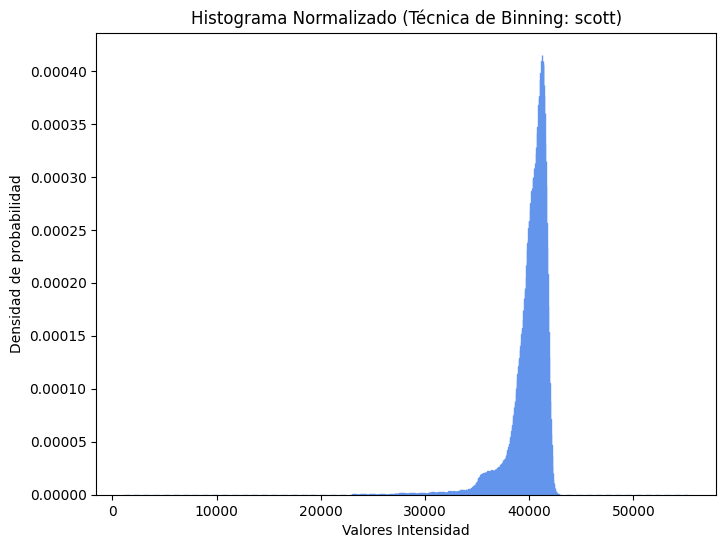

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos de ejemplo (reemplaza con tus datos)


# Técnicas de binning a considerar
binning_techniques = ['scott', 'sturges', 'rice']

# Función para calcular el MISE
def calculate_MISE(data, binning_technique):
    # Calcular el ancho de los bins usando el método especificado
    if binning_technique == 'scott':
        bin_width = 3.5 * np.std(data) / (len(data) ** (1/3))
    elif binning_technique == 'sturges':
        bin_width = 2 * np.std(data) / np.sqrt(len(data))
    elif binning_technique == 'rice':
        bin_width = 2 * np.std(data) / (len(data) ** (1/3))

    num_bins = int((max(data) - min(data)) / bin_width)

    hist, bin_edges = np.histogram(data, bins=num_bins)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    density = hist / (np.sum(hist) * (bin_edges[1] - bin_edges[0]))
    true_density = stats.norm.pdf(bin_centers, np.mean(data), np.std(data))
    squared_error = (density - true_density) ** 2
    MISE = np.trapz(squared_error, x=bin_centers)
    return MISE

# Calcular el MISE para cada técnica de binning
MISE_values = {}
for technique in binning_techniques:
    MISE = calculate_MISE(I, technique)
    MISE_values[technique] = MISE

# Seleccionar la técnica con el menor MISE
best_binning_technique = min(MISE_values, key=MISE_values.get)

# Crear el histograma con la técnica seleccionada
fig, axs = plt.subplots(figsize=(8, 6))
axs.hist(I, density=True, edgecolor='cornflowerblue', color="lightsteelblue", rwidth=0.6, bins=best_binning_technique)
axs.set_xlabel('Valores Intensidad')
axs.set_ylabel('Densidad de probabilidad')
axs.set_title(f'Histograma Normalizado (Técnica de Binning: {best_binning_technique})')

# Imprimir la técnica de binning seleccionada
print(f"La técnica de binning seleccionada es: {best_binning_technique}")




**Prueba de que esta normalizada**

In [ ]:
I_norm=np.histogram(I, density=True,  bins='scott')
n_bin=len(I_norm[0])
suma_I=sum(I_norm[0])
tamaño_bin=np.diff(I_norm[1])[0]

Integral=suma_I*tamaño_bin
Integral

1.0000000000000058

In [ ]:
n_bin

1185

EL density true fuciona pues la integral bajo la curva es 1. YUJU!!

### **Comparación momentos con el histograma**

para que compare sus momentos con lo que muestra el histograma. Interprete sus resultados.

In [ ]:
#CODIGO DE VARIAS GRAFICAS DONDE PONGA LA GAUSSIANA EN CADA PEZASOS , MOVERLAS VARIAS VECES


In [ ]:
I_norm

(array([5.2208448e-09, 5.2208448e-09, 0.0000000e+00, ..., 5.2208448e-09,
        0.0000000e+00, 5.2208448e-09]),
 array([ 1139.        ,  1184.66666667,  1230.33333333, ...,
        55162.66666667, 55208.33333333, 55254.        ]))

## **b)**
Habiendo estimado la intensidad media, estime la incertidumbre de dicha intensidad, y entregue un intervalo al $90 \%$ C.L. para esa medida. Estime dicho intervalo sin hacer uso de ningún tipo de distribución de probabilidad analítica, sino, la distribución original de intensidades de los pixeles (por ejemplo, haga uso del histograma del punto anterior). Describa en detalle como estima el intervalo y explique bien sus aproximaciones.

$$\alpha =0,1$$

In [ ]:
def fdc(dat):
  Num_dat=np.zeros(len(dat))
  sum_dat=np.zeros(len(dat))
  sum=0
  for i in range(len(dat)):
    sum+=dat[i]
    sum_dat[i]=sum
    Num_dat[i]=i+1
  return Num_dat,sum_dat



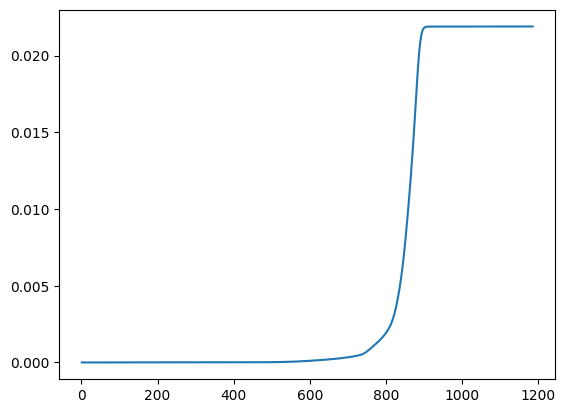

In [ ]:
plt.plot(fdc(I_norm[0])[0],fdc(I_norm[0])[1])

In [ ]:
α=0.1

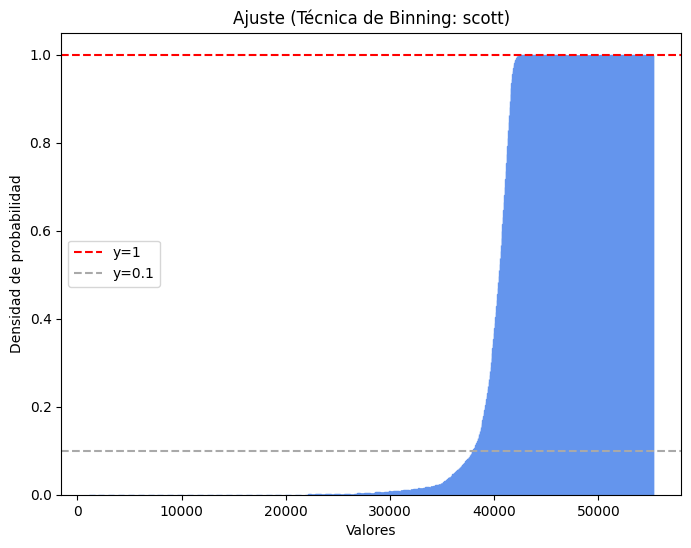

In [ ]:

# Crear el histograma con la técnica seleccionada
fig, axs = plt.subplots(figsize=(8, 6))
axs.hist(I, density=True,cumulative=True, edgecolor='cornflowerblue', color="lightsteelblue", rwidth=0.6, bins=best_binning_technique)
axs.set_xlabel('Valores')
axs.set_ylabel('Densidad de probabilidad')
axs.set_title(f'Ajuste (Técnica de Binning: {best_binning_technique})')

# Agregar una línea horizontal en y=1
axs.axhline(y=1, color='red', linestyle='--', label='y=1')
axs.axhline(y=α, color='darkgrey', linestyle='--', label='y=0.1')
plt.legend()  # Agregar una leyenda para la línea horizontal

# Mostrar el gráfico
plt.show()

$$p\left ( a\leq \theta\leq b \right )=\int_{a}^{b}f(x)dx$$

$$\frac{\alpha}{2}=\int_{\infty}^{a}f(x)dx$$


$$1-\frac{\alpha}{2}=\int_{-\infty}^{b}f(x)dx$$


In [ ]:
cort1=α/2
cort2=1-(α/2)
cort1,cort2

(0.05, 0.95)

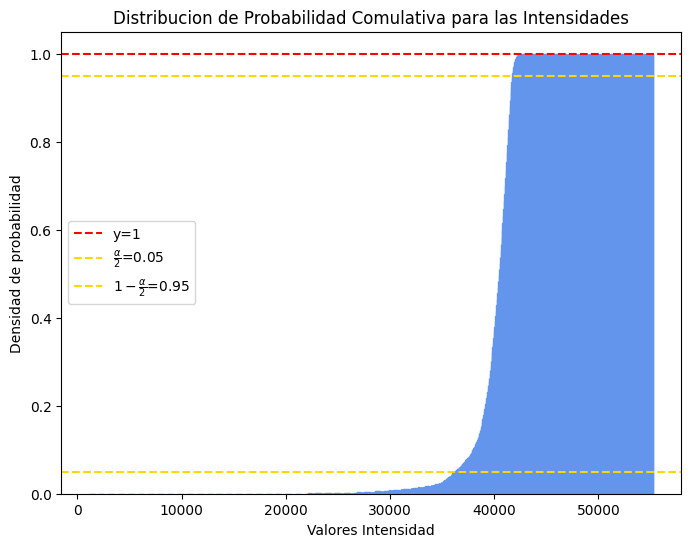

In [ ]:
import matplotlib.pyplot as plt

# Crear el histograma con la técnica seleccionada
plt.figure(figsize=(8, 6))
n_, bins_, patches = plt.hist(I, density=True, cumulative=True, edgecolor='cornflowerblue', color="lightsteelblue", rwidth=0.6, bins=best_binning_technique)
plt.xlabel('Valores Intensidad')
plt.ylabel('Densidad de probabilidad')
plt.title('Distribucion de Probabilidad Comulativa para las Intensidades')

# Agregar una línea horizontal en y=1
plt.axhline(y=1, color='red', linestyle='--', label='y=1')
plt.axhline(y=cort1, color='gold', linestyle='--', label=r'$\frac{\alpha}{2}$=' + str(cort1))
plt.axhline(y=cort2, color='gold', linestyle='--', label=r'$1-\frac{\alpha}{2}$=' + str(cort2))
#plt.axhline(y=α, color='darkgrey', linestyle='--', label='y=0.1')

plt.legend()  # Agregar una leyenda para la línea horizontal

# Mostrar el gráfico
plt.show()

In [ ]:
# Por ejemplo, para encontrar los elementos en n_ mayores que un valor específico (threshold):

indices_1 = np.where(n_ > cort1)[0][0]
indices_2 = np.where(n_ > cort2 )[0][0]

bins_[indices_1],bins_[indices_2]

(36165.33333333333, 41736.666666666664)

In [ ]:

bins_[indices_1]-momentos_sesgados(I)[0][0],bins_[indices_2] -momentos_sesgados(I)[0][0]

(-3793.978512684509, 1777.3548206488267)

$\lambda_{corte}$. Mi distribución no es simetrica, se estuio con las inferencias de los momentos d ela distribución. ESo signfica que para construir los intervalos de confianza debo de buscar hacer desde la forma general, para esto usemos el siguiente criterio:


El enunciado me dice que habiendo estimado la intensidad media , estime la incertidumbre de dicha intensidad. Es decir , alrededor de la media voy a obtener el intervalo de confianza. En el procedimiento general para obtener dicho intervalo según un nivel de signficancia era necesario asumir una distribucion para obtener los valores en las tablas de valores de corte, en este caso no se tiene una distribución analitica que permita obtener valores de corte de las tablas, asi que los valores de corte que se obtienen usando la distribucion acomulativa para la cual io es necesario la estandarizacion, asi los valores de corte obtenidos corresponden directamente a los limites de intervalos de confianza.



###**Función Comulativa**

In [ ]:
2049

2049

## **c)**

La imagen con la que está trabajando tiene $2048 \times 2048$ piexeles. Subdivida la imagen en $N$ subimágenes más pequeñas ( $N$ debe ser $>4$, y las subimágenes no necesariamente deben ser cuadradas). Para cada subimagen estime la intensidad media usando dos estimadores diferentes (para esto, puede recordar por ejemplo que el número de cuentas en un pixel es una variable poissoniana con una varianza dada). Estudie y compare la consistencia, bias y varianza de cada uno de los dos estimadores. ¿Cuál de los dos sería mejor? Justifique sus procedimientos y conclusiones.

###**Consistencia**

In [ ]:
#HACER L SLIDE PARA CUALQUIER CHIMBADA PARA SABER COMO FUNCIONA

In [ ]:
var=np.array([2**(3),2**(4),2**(5),2**(6),2**(7),2**(8)])
var

array([  8,  16,  32,  64, 128, 256])

In [ ]:
def estima(xi,shha):
  n_data=(shha*2048)
  est1=(sum(sum(xi**(1/2))))/(sum(sum(xi**(-1/2))))
  est2=(1/n_data)*(sum(sum(xi)))
  est3=(xi.max()+xi.min())/2
  return est1, est2, est3
def esti1(arre):
  return (sum(arre**(1/2)))/(sum(arre**(-1/2)))

def esti2(arre):
  return (1/len(arre))*(sum(arre))

def esti3(arre):
  return (arre.max()+arre.min())/2



In [ ]:
def consistencia(xx):
  #Defino los datos
  total=2048
  cant_ima=xx
  n_corte=int(2048/(cant_ima))#CANTIDAD DE MUESTRAS
  n_corte,cant_ima

  #Separo mis particiones
  muestras=np.zeros([n_corte,cant_ima,total])

  for j in range(n_corte):
    for i in range(cant_ima):
        start_idx = j * cant_ima * total + i * total
        end_idx = start_idx + total
        muestras[j][i] = I[start_idx:end_idx]

  #Lleno mi medias de medias
  values=np.zeros([n_corte,3])

  for i in range(n_corte):
    values[i]=estima(muestras[i],cant_ima)

  return esti1(values[:, 0]),esti2(values[:, 1]),esti3(values[:, 2])


In [ ]:
consistencia(var[2])

(39884.0014867873, 39959.31184601784, 30780.5)

In [ ]:
data_c=np.zeros([len(var),3])


In [ ]:
for i in range(len(var)):
  data_c[i]=consistencia(var[i])

TEngo las estimaciones de las medias de medias




In [ ]:
data_c


array([[39884.72756241, 39959.31184602, 30780.5       ],
       [39884.28133606, 39959.31184602, 30780.5       ],
       [39884.00148679, 39959.31184602, 30780.5       ],
       [39883.81115071, 39959.31184602, 30724.5       ],
       [39883.63361791, 39959.31184602, 30683.75      ],
       [39883.39113952, 39959.31184602, 30943.25      ]])

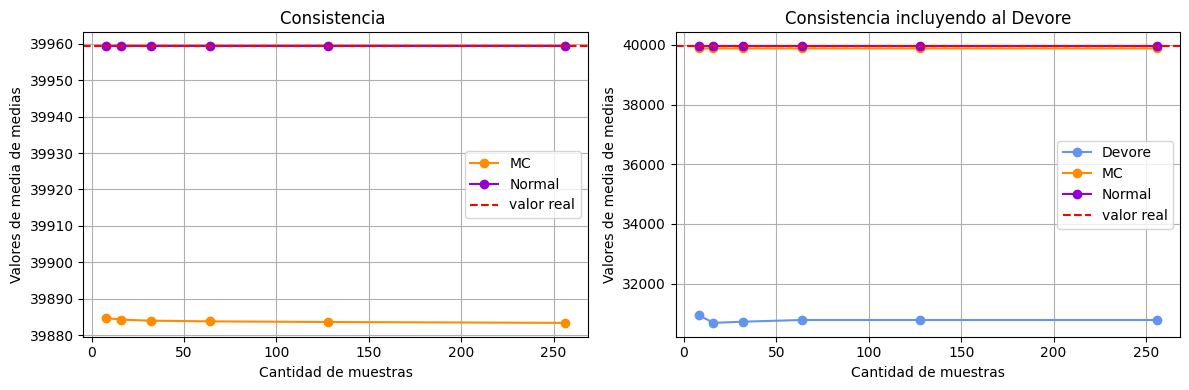

In [ ]:
resu = 2048 / var

fig, ax = plt.subplots(1, 2, figsize=(12, 4))  # Crear un subplot de 1 fila y 2 columnas

# Primer gráfico en ax[0]
ax[0].plot(var, data_c[:, 0], color='darkorange', label='MC', marker='o')
ax[0].plot(resu, data_c[:, 1], color='darkviolet', label='Normal', marker='o')
ax[0].axhline(y=momentos_sesgados(I)[0][0], color='red', linestyle='--', label='valor real')

ax[0].set_xlabel('Cantidad de muestras')
ax[0].set_ylabel('Valores de media de medias')
ax[0].set_title('Consistencia ')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(resu, data_c[:, 2], color='cornflowerblue', label='Devore', marker='o')
ax[1].plot(resu, data_c[:, 0], color='darkorange', label='MC', marker='o')
ax[1].plot(resu, data_c[:, 1], color='darkviolet', label='Normal', marker='o')
ax[1].axhline(y=momentos_sesgados(I)[0][0], color='red', linestyle='--', label='valor real')
ax[1].set_xlabel('Cantidad de muestras')
ax[1].set_ylabel('Valores de media de medias')
ax[1].set_title('Consistencia incluyendo al Devore')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()



Vemos que a medida que aumenta el número de de particiones , disminuye el numero de datos , asi segun nuestra grafica a medida que aumenta el numero de muestras disminuye.

###**Consistencia**

###**Varianza**

In [ ]:

def varian(xx):
  #Defino los datos
  total=2048
  cant_ima=xx
  n_corte=int(2048/(cant_ima))#CANTIDAD DE MUESTRAS
  n_corte,cant_ima

  #Separo mis particiones
  muestras=np.zeros([n_corte,cant_ima,total])

  for j in range(n_corte):
    for i in range(cant_ima):
        start_idx = j * cant_ima * total + i * total
        end_idx = start_idx + total
        muestras[j][i] = I[start_idx:end_idx]

  #Lleno mi medias de medias
  values=np.zeros([n_corte,3])

  for i in range(n_corte):
    values[i]=estima(muestras[i],cant_ima)
  #Calculo la media de medias para cada estimador:
  mm1=esti1(values[:, 0])
  mm2=esti2(values[:, 1])
  mm3=esti3(values[:, 2])

  #Calculamos el segundo momento
  len(values[:, 0])
  valor_ver=momentos_sesgados(I)[0][0]
  var1=(1/len(values[:, 0]))*sum(pow((values[:, 0]-valor_ver),2))
  var2=(1/len(values[:, 1]))*sum(pow((values[:, 1]-valor_ver),2))
  var3=(1/len(values[:, 2]))*sum(pow((values[:, 2]-valor_ver),2))

  return var1,var2,var3

In [ ]:
data_var=np.zeros([len(var),3])

In [ ]:
for i in range(len(var)):
  data_var[i]=varian(var[i])

In [ ]:
data_var

array([[ 2199177.96712675,  1851900.48462544,  7992852.36458605],
       [ 2136357.33857267,  1823499.98840903,  9048758.17614076],
       [ 2088890.41329974,  1804083.71210984, 11239126.94464709],
       [ 2039954.7404274 ,  1778335.78172486, 15819515.71900604],
       [ 1947163.55838894,  1712293.33042779, 25548686.43354094],
       [ 1689929.4241593 ,  1499940.12881309, 43956178.97188076]])

###**Bias**

In [ ]:
media_verd=momentos_sesgados(I)[0][0]

In [ ]:
sesgo = np.abs(data_c - media_verd)
sesgo



array([[  74.58428361,    0.        , 9178.81184602],
       [  75.03050996,    0.        , 9178.81184602],
       [  75.31035923,    0.        , 9178.81184602],
       [  75.50069531,    0.        , 9234.81184602],
       [  75.67822811,    0.        , 9275.56184602],
       [  75.9207065 ,    0.        , 9016.06184602]])

Comparemos con 3 estimadores de la media:

De minimos cuadrados cuando se busco el valor de de la metrica que minimiazba respecto al paramtro de l media , no dios:
$$\mu=∑

Distribucion Weibull (skewness negativo con paramettro fraccionario), gamma, lognormal

## **d)**




Durante la observación, un estudiante confundió los archivos de los flat fields, y necesita verificar si uno de ellos está mal clasificado (el archivo se llama flat_perdido.pix).

Cómo podría usar la información de su flat-field y la imagen del flat dudoso para verificar (con un nivel de significancia del 5\%) si el flat dudoso es o no es parte de esa observación? Haga la prueba correspondiente. Explique la manera como formula su prueba y de las justificaciones del caso.

In [ ]:
ruta_archivo2 = '/content/flat_perdido.pix.gz'



# Lee el archivo de texto en un DataFrame de Pandas
data2 = pd.read_csv(ruta_archivo2, sep='\s+', header=None, names=["Coordenada x", "Coordenada y", "I(x,y)"], dtype={"Columna3": int})

# Muestra el DataFrame
data2

,Coordenada x,Coordenada y,"I(x,y)"
0,1.0,1.0,1039.0
1,2.0,1.0,1394.0
2,3.0,1.0,1557.0
3,4.0,1.0,1640.0
4,5.0,1.0,1639.0
...,...,...,...
4194299,2044.0,2048.0,8197.0
4194300,2045.0,2048.0,8431.0
4194301,2046.0,2048.0,8345.0
4194302,2047.0,2048.0,8211.0


In [ ]:
I2=np.array(data2.iloc[:, 2]) #COLUMNAS
x2=np.array(data2.iloc[:, 0])
y2=np.array(data2.iloc[:, 1])

In [ ]:
I2

array([1039., 1394., 1557., ..., 8345., 8211., 7911.])

###**HIPOTESIS ALTERNATIVA E HIPOTESIS NULA**

Quiero verificiar si el flat es parte de mis observaciones , debo de estudiarlo respecto a la media , asi que

###**NIVEL DE SIGNFICANCIA**

HOla, estoy haciendo una prueba de hipotesis a dos muestras usando el estadistico z a dos colas para un nivel de signficacncia del 5%, me ayudarias haciendo un algoritmo para determinar los z corte para la distribucion normal y para tomar la decision calculando el estadistico:

In [ ]:

# Nivel de significancia (alpha) PARA DOS COLAS
α_per=0.05/2

###**CALCULO DEL ESTADISTICO DE PRUEBA**

In [ ]:
# Muestra 1 y muestra 2 (media y desviación estándar)
mean1 =  momentos_sesgados(I)[0][0]


std1 = np.std(I, ddof=1)


mean2 =  momentos_sesgados(I2)[0][0]

std2 = np.std(I2, ddof=1)

In [ ]:
mean1,mean2

(39959.31184601784, 12758.825673818588)

In [ ]:
len(I)

4194304

In [ ]:
# Cálculo de grados de libertad
n1 = len(I)
n2 = len(I2)
df = n1 + n2 - 2  # Grados de libertad

# Cálculo del valor crítico de T

t_critical = stats.t.ppf(1 - α_per, df)  # Valor crítico de T
t_critical,df

(1.9599642673369295, 8388606)

In [ ]:
import numpy as np
from scipy import stats


pooled_std = np.sqrt(((((n1 - 1) * std1 ** 2) + ((n2 - 1) * std2 ** 2))) / (df))

t_statistic = (mean1 - mean2) / (pooled_std * np.sqrt(1 / n1 + 1 / n2))

# Decisión de la prueba de hipótesis
if abs(t_statistic) > t_critical:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

# Opcional: también puedes calcular el valor p
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))
print("Valor p:", p_value)
print("estadistico t:", t_statistic)


Se rechaza la hipótesis nula
Valor p: 0.0
estadistico t: 24553.203636913706


In [ ]:
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))
p_value

0.0

###**TOMA DE DESICIÓN**

In [ ]:
#TEOREMA DEL LIMTE CENTRAL PARA COMPARAR DOS MUESTRAS RESPECTO A LA MEDIA

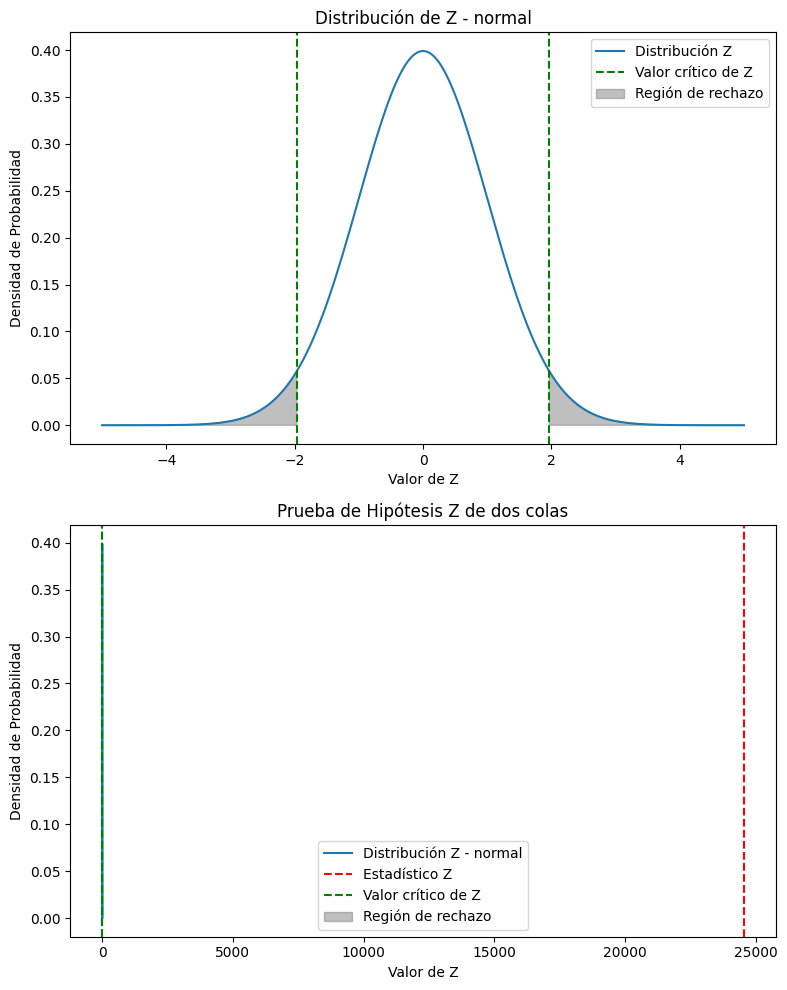

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


# Creación de un conjunto de valores T para graficar
t_values = np.linspace(-5, 5, 400)
pdf = stats.t.pdf(t_values, df)  # Distribución t de Student

# Cálculo del valor crítico de T
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df)  # Valor crítico de T

pooled_std = np.sqrt(((n1 - 1) * std1 ** 2 + (n2 - 1) * std2 ** 2) / df)

t_statistic = (mean1 - mean2) / (pooled_std * np.sqrt(1 / n1 + 1 / n2))

# Creación de la figura y subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

# Subplot 1: Distribución t
ax[0].plot(t_values, pdf, label='Distribución Z ')
ax[0].axvline(t_critical, color='green', linestyle='--', label='Valor crítico de Z')
ax[0].axvline(-t_critical, color='green', linestyle='--')
ax[0].set_title('Distribución de Z - normal')
ax[0].fill_between(t_values, 0, pdf, where=(t_values > t_critical) | (t_values < -t_critical), color='gray', alpha=0.5, label='Región de rechazo')
ax[0].set_xlabel('Valor de Z')
ax[0].set_ylabel('Densidad de Probabilidad')

# Subplot 2: Estadístico T y Valor crítico de T
ax[1].plot(t_values, pdf, label='Distribución Z - normal')
ax[1].axvline(t_statistic, color='red', linestyle='--', label='Estadístico Z')
ax[1].axvline(t_critical, color='green', linestyle='--', label='Valor crítico de Z')
ax[1].axvline(-t_critical, color='green', linestyle='--')
ax[1].fill_between(t_values, 0, pdf, where=(t_values > t_critical) | (t_values < -t_critical), color='gray', alpha=0.5, label='Región de rechazo')
ax[1].set_title('Prueba de Hipótesis Z de dos colas')
ax[1].set_xlabel('Valor de Z')
ax[1].set_ylabel('Densidad de Probabilidad')

# Mostrar las leyendas en ambos subplots
ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy import stats

# Nivel de significancia (alpha) PARA DOS COLAS
alpha_per = 0.05 / 2

# Muestra 1 y muestra 2 (media y desviación estándar)
mean1 = np.mean(I)
std1 = np.std(I, ddof=1)
mean2 = np.mean(I2)
std2 = np.std(I2, ddof=1)

# Tamaño de las muestras
n1 = len(I)
n2 = len(I2)

# Cálculo del valor crítico de Z
z_critical = stats.norm.ppf(1 - alpha_per)

# Cálculo de la desviación estándar conjunta
pooled_std = np.sqrt((std1**2 / n1) + (std2**2 / n2))

# Cálculo del estadístico Z
z_statistic = (mean1 - mean2) / pooled_std

# Decisión de la prueba de hipótesis
if abs(z_statistic) > z_critical:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

# Cálculo del error de tipo II
beta = 1 - stats.norm.cdf(z_statistic)

print("Valor crítico Z:", z_critical)
print("Estadístico Z:", z_statistic)
print("Error de tipo II (beta):", beta)


Se rechaza la hipótesis nula
Valor crítico Z: 1.959963984540054
Estadístico Z: 24553.203636913713
Error de tipo II (beta): 0.0


In [ ]:
momentos_sesgados(I2)[0]

[12758.825673818588, 695793.1822671216, -2.6116839662169347, 18.9319464739648]

La técnica de binning seleccionada es: scott


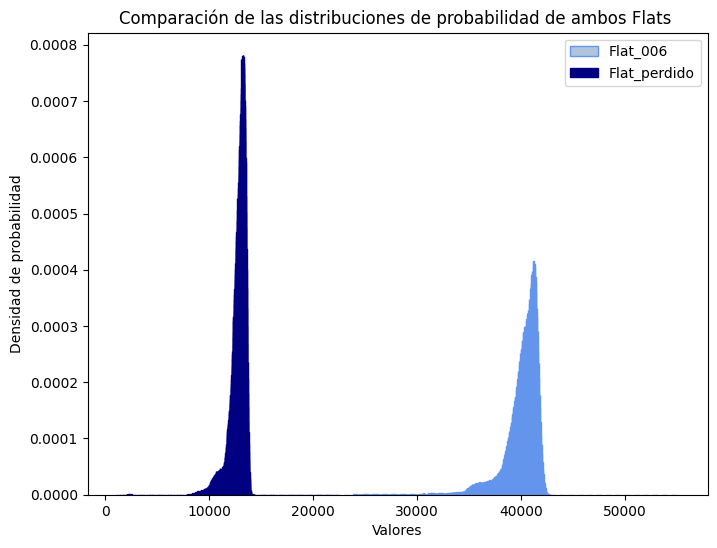

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos de ejemplo (reemplaza con tus datos)


# Técnicas de binning a considerar
binning_techniques = ['scott', 'sturges', 'rice']

# Función para calcular el MISE
def calculate_MISE(data, binning_technique):
    # Calcular el ancho de los bins usando el método especificado
    if binning_technique == 'scott':
        bin_width = 3.5 * np.std(data) / (len(data) ** (1/3))
    elif binning_technique == 'sturges':
        bin_width = 2 * np.std(data) / np.sqrt(len(data))
    elif binning_technique == 'rice':
        bin_width = 2 * np.std(data) / (len(data) ** (1/3))

    num_bins = int((max(data) - min(data)) / bin_width)

    hist, bin_edges = np.histogram(data, bins=num_bins)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    density = hist / (np.sum(hist) * (bin_edges[1] - bin_edges[0]))
    true_density = stats.norm.pdf(bin_centers, np.mean(data), np.std(data))
    squared_error = (density - true_density) ** 2
    MISE = np.trapz(squared_error, x=bin_centers)
    return MISE

# Calcular el MISE para cada técnica de binning
MISE_values = {}
for technique in binning_techniques:
    MISE = calculate_MISE(I, technique)
    MISE_values[technique] = MISE

# Seleccionar la técnica con el menor MISE
best_binning_technique = min(MISE_values, key=MISE_values.get)

# Crear el histograma con la técnica seleccionada
fig, axs = plt.subplots(figsize=(8, 6))
axs.hist(I, density=True, edgecolor='cornflowerblue', color="lightsteelblue", rwidth=0.6, bins=best_binning_technique,label='Flat_006')
axs.hist(I2, density=True, edgecolor='navy', color="navy", rwidth=0.6, bins=best_binning_technique,label='Flat_perdido')
axs.set_xlabel('Valores')
axs.set_ylabel('Densidad de probabilidad')
axs.set_title(f'Comparación de las distribuciones de probabilidad de ambos Flats ')
axs.legend()

# Imprimir la técnica de binning seleccionada
print(f"La técnica de binning seleccionada es: {best_binning_technique}")